In [1]:
import numpy as np
import itertools
from pyspark.sql import SparkSession
import time
np.random.seed(42)

In [2]:
import os, sys
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Ali'sSimHash") \
    .master("local[*]") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()


In [3]:
def read_fvecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    return data[:, 1:].view(np.float32)

def read_ivecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    return data[:, 1:]

In [20]:
def random_normal_matrix(m, d, seed = 42):
    return np.random.default_rng(seed).standard_normal((m, d)).astype(np.float32)

def compute_signature(q, hyperPlanesMatrix):

    results = hyperPlanesMatrix @ q.T
    sig = (results > 0).T.astype(np.bool_)
    return  sig
def signature_to_band(signature_1d, b):

    m = signature_1d.shape[0]
    r = m // b
    bands = []
    for idx in range(b):
        start = idx * r
        end = (idx + 1) * r
        band_bits = signature_1d[start:end].astype(np.uint8)
        if r <= 64:
            bit_str = "".join(band_bits.astype(str))
            val = int(bit_str, 2)
        else:
            bit_str = "".join(band_bits.astype(str))
            val = int(bit_str, 2)
        bands.append((idx, val))
    return bands
def emit_bands(item, b):
        doc_id, signature = item
        signatures = np.array(signature, dtype=bool)
        # doc_ids ia a list of doc ids in the same band bucket
        res = [((bi, bv), doc_id) for bi, bv in signature_to_band(signatures, b)]
        return res

def emit_pairs(item):
     _, doc_ids = item
     return [(min(a, b_), max(a, b_)) for a, b_ in itertools.combinations(doc_ids, 2)]

def k_to_cosine_threshold(k, m):
    theta = (k / m) * np.pi
    return float(np.cos(theta))

def evaluate_k(candidates, base, k, m):
    theoretical_threshold = k_to_cosine_threshold(k, m)
    if(theoretical_threshold < 0.85):
        return -1
    good = 0
    total = len(candidates)

    for i, j in candidates:
        cos_sim = float(np.dot(base[i], base[j]))
        if(cos_sim >= theoretical_threshold):
            good += 1
    
    quality = 0.0

    if(good > 0):
        quality = good / total

    return {
        "k": k,
        "threshold": theoretical_threshold,
        "num_good": good,
        "num_candidates": total,
        "quality": quality

    }

def evaluate_k_optimized(candidates, C, k, m):
    theoretical_threshold = k_to_cosine_threshold(k, m)
    if(theoretical_threshold < 0.85):
        return -1
    similarities = np.array([C[i, j] for i, j in candidates])
    good = np.sum(similarities >= theoretical_threshold)
    total = len(candidates)
    quality = 0.0
    if(good > 0):
        quality = good / total
    return {
        "k": k,
        "threshold": theoretical_threshold,
        "num_good": good,
        "num_candidates": total,
        "quality": quality

    }

def evaluate_all_candidates(pairs, signatures, vectors, k, m, min_threshold = 0.85):

    TP = 0
    FN = 0
    FP = 0
    detected = 0
    expected_list = []
    actual_list = []


    for (i, j) in pairs:
        
        h = np.count_nonzero(signatures[i] != signatures[j])
        actual_similarity = vectors[i] @ vectors[j].T

        is_good_candidate = actual_similarity >= min_threshold

        if h <= k:
            detected += 1
            expected_similarity = np.cos(np.pi * (h/m))
            expected_list.append(expected_similarity)
            actual_list.append(actual_similarity)

            if is_good_candidate:
                TP += 1
            else:
                FP += 1
        else:
            if is_good_candidate:
                FN += 1

    # Computing scores

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    F1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    mse = float(np.mean((np.array(expected_list) - np.array(actual_list)) ** 2)) if expected_list else None
    mae = float(np.mean(np.abs(np.array(expected_list) - np.array(actual_list)))) if expected_list else None

    return{
        "k": k,
        "m": m,
        "sim_threshold": min_threshold,
        "num_candidates_total": len(pairs),
        "num_detected_h_at_most_k": detected,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "F1": F1,
        "expected_actual_mse": mse,
        "expected_actual_mae": mae

    }



In [5]:
def init_run_simhash(sparkSession, vectors, m, b, signatures, seed=42):

    print("signatures shape:", signatures.shape)  # (n_docs, m)

    # enumerate documents
    indexed = list(enumerate(signatures))  # list of (doc_id, signature_list)

    rdd = sparkSession.sparkContext.parallelize(indexed, numSlices=8)

    band_rdd = rdd.flatMap(lambda x: emit_bands(x, b))

    # group by band key and keep buckets with at least 2 docs
    grouped = (band_rdd.groupByKey()
                        .mapValues(list)
                        .filter(lambda x: len(x[1]) >= 2))

    # for all pairs within each bucket
    candidate_pairs = grouped.flatMap(emit_pairs).distinct().collect()


    return set(candidate_pairs)

In [6]:
SIFT_paths = {
    "small": {
        "base": "./data/small/siftsmall_base.fvecs",
        "gt": "./data/small/siftsmall_groundtruth.ivecs",
        "queries": "./data/small/siftsmall_query.fvecs"
    },
    "large": {
        "base": "./data//sift_base.fvecs",
        "gt": "./data/sift_groundtruth.ivecs",
        "queries": "./data/sift_query.fvecs"
    }
}

N_VECTORS = 500
THRESHOLD = 0.9
SEED = 42



mode = "small"

base = read_fvecs(SIFT_paths[mode]["base"])
queries = read_fvecs(SIFT_paths[mode]["queries"])
groundTruts = read_ivecs(SIFT_paths[mode]["gt"])

base_normalized = base / np.linalg.norm(base, axis=1, keepdims=True)
queries_normalized = queries / np.linalg.norm(queries, axis=1, keepdims=True)

print(f"Loaded data successfully.\nShape: {base_normalized.shape}")

Loaded data successfully.
Shape: (10000, 128)


In [23]:
#spark = SparkSession.builder.appName("Ali'sSimHash").master("local[*]").config("spark.ui.showConsoleProgress", "false").getOrCreate()


# bVals = [4, 8, 16, 32]
# mVals = [64, 128, 256, 512, 1024] 
# kVals = [0, 1,2, 4, 8, 16, 32]

bVals = [2, 4, 8]
mVals = [64, 128, 256, 1024] 
kVals = [0, 1, 2, 4, 8, 16, 32]
results = []

MIN_THRESHOLD = 0.85

idx = np.random.choice(base_normalized.shape[0], size=1000, replace=False)
base_samples = base_normalized[idx]

vectors = base_samples

print("Working with: " , vectors.shape)

for m in mVals:
    for b in bVals:
        if (m % b != 0):
            # illegal pair,
            continue
    
        hyperPlanes = random_normal_matrix(m, vectors.shape[1], SEED)
        # compute signatures: (n_docs, m)
        signatures = compute_signature(vectors, hyperPlanes)
        
        r = m / b
        t0 = time.perf_counter()
        candidates = init_run_simhash(spark, vectors, m, b,signatures, seed=SEED)
        t0 = time.perf_counter() - t0
        print(t0)
        for k in kVals:
            #if(b > k):
            res = evaluate_all_candidates(candidates, signatures, vectors, k, m, MIN_THRESHOLD)
            if(res != -1):
                res.update([("m", m), ("b", b), ("time_to_find_candidates, s", t0)])
                res["config_id"] = f",={m}, b={b}, k={k}"
                results.append(res)

    


Working with:  (1000, 128)
signatures shape: (1000, 64)
64.14577059999283
signatures shape: (1000, 64)
65.4316805999988
signatures shape: (1000, 64)
65.6066140000039
signatures shape: (1000, 128)
64.41901030000008
signatures shape: (1000, 128)
73.23116300000402
signatures shape: (1000, 128)
66.38400950000505
signatures shape: (1000, 256)
66.67791280000529
signatures shape: (1000, 256)
67.76706939999713
signatures shape: (1000, 256)
68.37121210001351
signatures shape: (1000, 1024)
72.58239460000186
signatures shape: (1000, 1024)
79.69045829999959
signatures shape: (1000, 1024)
71.1638127000042


In [ ]:
results

[{'k': 0,
  'm': 64,
  'sim_threshold': 1.0,
  'num_candidates_total': 5241,
  'num_detected_h_at_most_k': 1,
  'TP': 0,
  'FP': 1,
  'FN': 0,
  'precision': 0.0,
  'recall': 0.0,
  'F1': 0.0,
  'expected_actual_mse': 5.45422950892771e-06,
  'expected_actual_mae': 0.0023354291915893555,
  'b': 4,
  'time_to_find_candidates, s': 58.413710699998774,
  'config_id': ',=64, b=4, k=0'},
 {'k': 1,
  'm': 64,
  'sim_threshold': 0.9987954562051724,
  'num_candidates_total': 5241,
  'num_detected_h_at_most_k': 8,
  'TP': 0,
  'FP': 8,
  'FN': 0,
  'precision': 0.0,
  'recall': 0.0,
  'F1': 0.0,
  'expected_actual_mse': 0.0036738606138518636,
  'expected_actual_mae': 0.04405265867716837,
  'b': 4,
  'time_to_find_candidates, s': 58.413710699998774,
  'config_id': ',=64, b=4, k=1'},
 {'k': 2,
  'm': 64,
  'sim_threshold': 0.9951847266721969,
  'num_candidates_total': 5241,
  'num_detected_h_at_most_k': 18,
  'TP': 2,
  'FP': 16,
  'FN': 0,
  'precision': 0.1111111111111111,
  'recall': 1.0,
  'F1'

In [ ]:
import pandas as pd

df2 = pd.DataFrame(results)
df2.to_pickle("res1_new_metrics3.pkl")

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
df2

,k,m,sim_threshold,num_candidates_total,num_detected_h_at_most_k,TP,FP,FN,precision,recall,F1,expected_actual_mse,expected_actual_mae,b,"time_to_find_candidates, s",config_id
0,0,64,0.85,5414,0,0,0,318,0.000000,0.000000,0.000000,NaN,NaN,4,52.818520,",=64, b=4, k=0"
1,1,64,0.85,5414,2,2,0,316,1.000000,0.006289,0.012500,0.000601,0.022188,4,52.818520,",=64, b=4, k=1"
2,2,64,0.85,5414,11,9,2,309,0.818182,0.028302,0.054711,0.006892,0.054326,4,52.818520,",=64, b=4, k=2"
3,0,64,0.85,127142,0,0,0,1669,0.000000,0.000000,0.000000,NaN,NaN,8,51.702936,",=64, b=8, k=0"
4,1,64,0.85,127142,2,2,0,1667,1.000000,0.001198,0.002394,0.000601,0.022188,8,51.702936,",=64, b=8, k=1"
5,2,64,0.85,127142,11,9,2,1660,0.818182,0.005392,0.010714,0.006892,0.054326,8,51.702936,",=64, b=8, k=2"
6,4,64,0.85,127142,75,53,22,1616,0.706667,0.031756,0.060780,0.013152,0.089048,8,51.702936,",=64, b=8, k=4"
7,0,64,0.85,473977,0,0,0,2002,0.000000,0.000000,0.000000,NaN,NaN,16,54.293613,",=64, b=16, k=0"
8,1,64,0.85,473977,2,2,0,2000,1.000000,0.000999,0.001996,0.000601,0.022188,16,54.293613,",=64, b=16, k=1"
9,2,64,0.85,473977,11,9,2,1993,0.818182,0.004496,0.008942,0.006892,0.054326,16,54.293613,",=64, b=16, k=2"


In [1]:
import pandas as pd
pd.__version__

'3.0.3'

In [4]:
df = pd.read_pickle("res2.pkl")

C:\Users\Ali\AppData\Local\Temp\ipykernel_4868\974718630.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', bbox_to_anchor=(1,1))


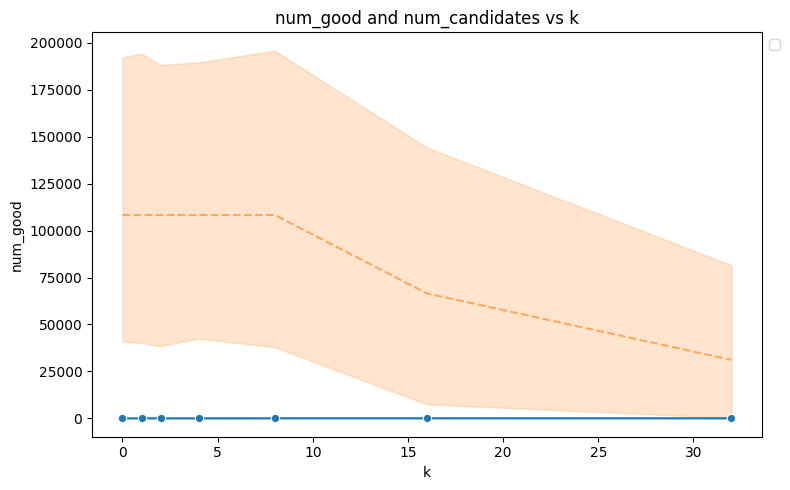

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# assume df is your results DataFrame
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='k', y='num_good', marker='o')
sns.lineplot(data=df, x='k', y='num_candidates', linestyle='--', alpha=0.6)
plt.yscale('linear')
plt.title('num_good and num_candidates vs k')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()


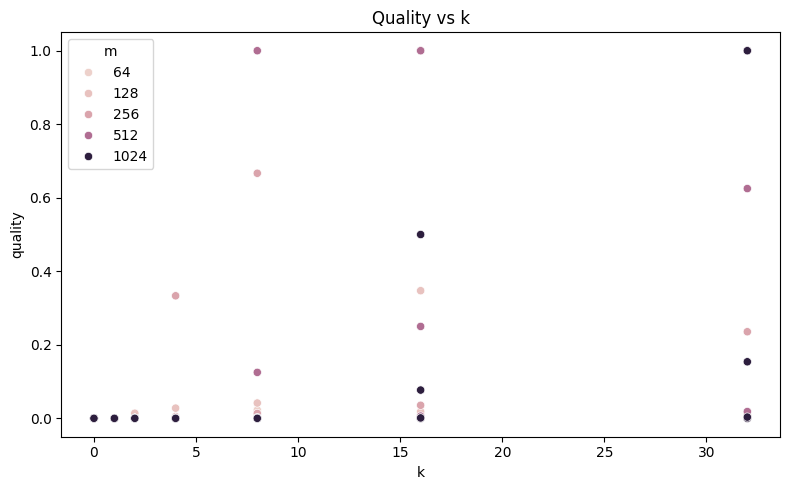

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='k', y='quality',hue="m", marker='o')
plt.title('Quality vs k')
plt.tight_layout()


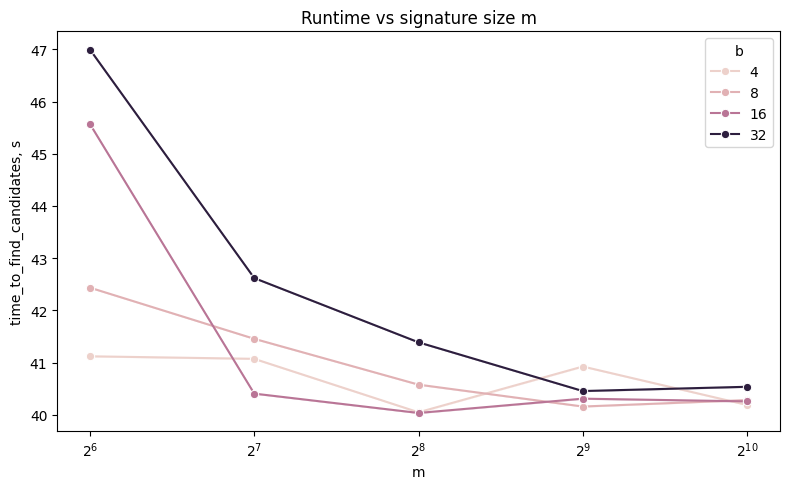

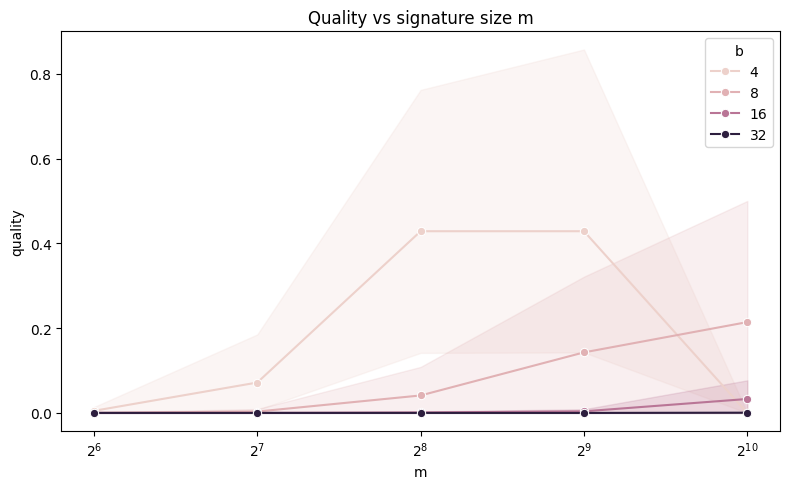

In [14]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='m', y='time_to_find_candidates, s', hue='b', marker='o')
plt.xscale('log', base=2)
plt.title('Runtime vs signature size m')
plt.tight_layout()

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='m', y='quality', hue='b', marker='o')
plt.xscale('log', base=2)
plt.title('Quality vs signature size m')
plt.tight_layout()


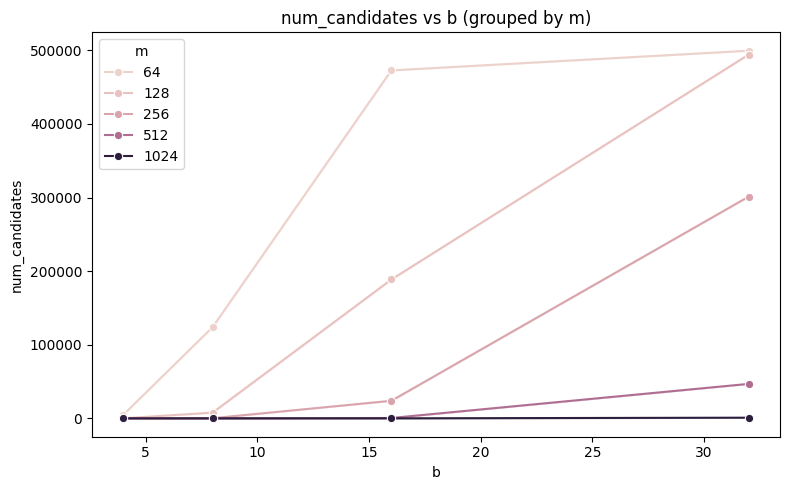

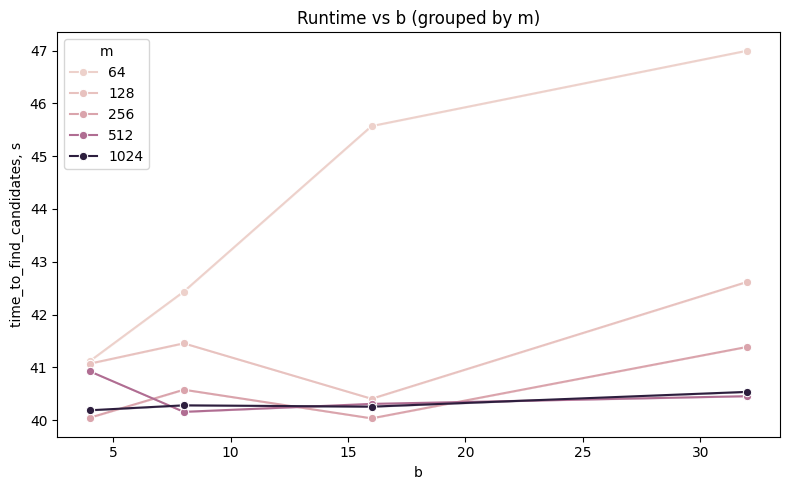

In [16]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='b', y='num_candidates', hue='m', marker='o')
plt.title('num_candidates vs b (grouped by m)')
plt.tight_layout()

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='b', y='time_to_find_candidates, s', hue='m', marker='o')
plt.title('Runtime vs b (grouped by m)')
plt.tight_layout()



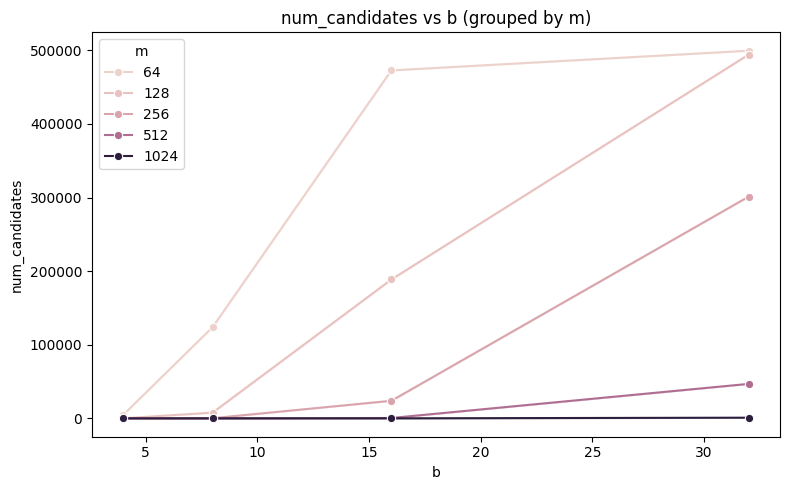

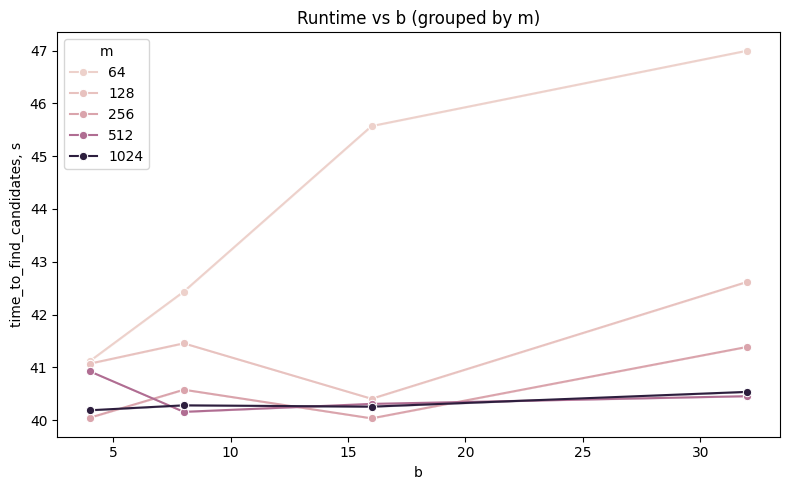

In [17]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='b', y='num_candidates', hue='m', marker='o')
plt.title('num_candidates vs b (grouped by m)')
plt.tight_layout()

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='b', y='time_to_find_candidates, s', hue='m', marker='o')
plt.title('Runtime vs b (grouped by m)')
plt.tight_layout()


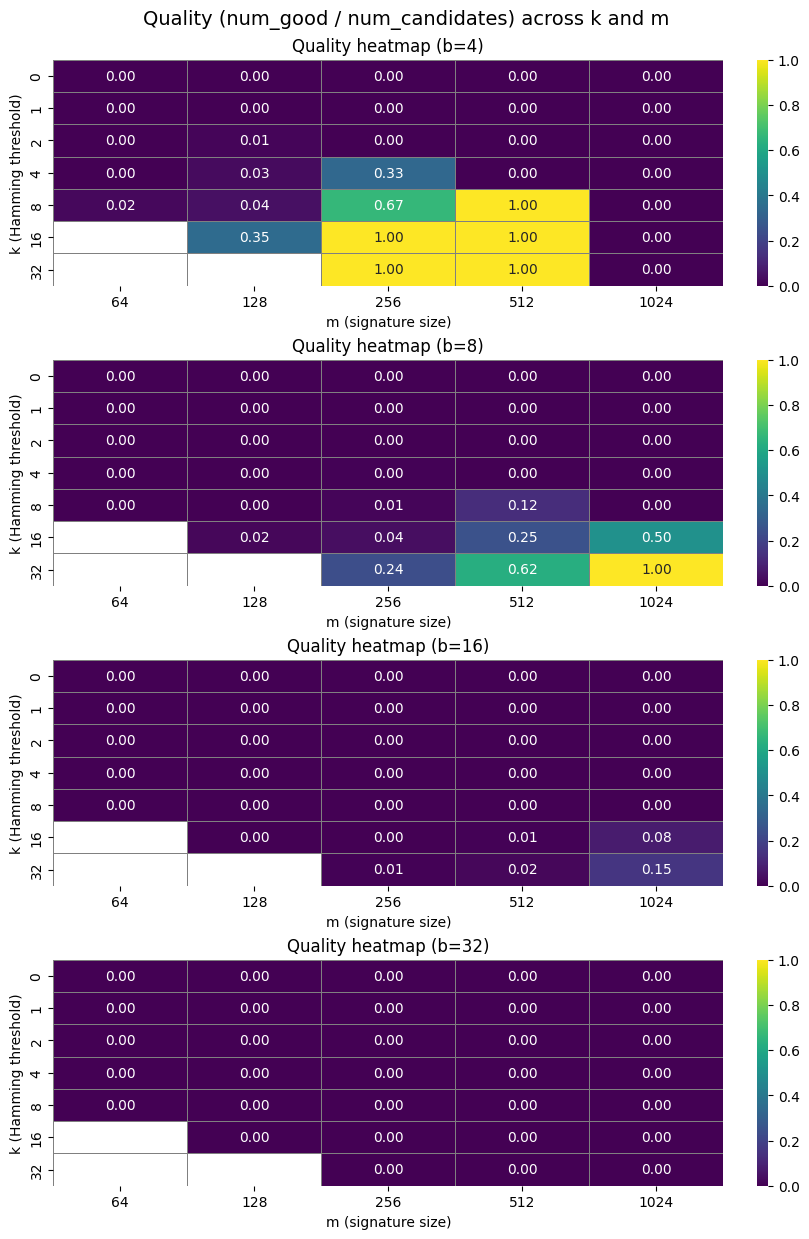

In [19]:
m_order = sorted(df['m'].unique())
k_order = sorted(df['k'].unique())

# list of b values in ascending order
b_values = sorted(df['b'].unique())

# plotting parameters
cmap = "viridis"          # or "rocket_r", "magma", "coolwarm"
annot = True             # set True to annotate quality numbers in cells
fmt = ".2f"

# create a grid of subplots (one row per b)
n = len(b_values)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(max(8, len(m_order)*0.6), 3*n), constrained_layout=True)

if n == 1:
    axes = [axes]

for ax, b in zip(axes, b_values):
    sub = df[df['b'] == b]
    # pivot: rows=k, cols=m
    pivot = sub.pivot_table(index='k', columns='m', values='quality', aggfunc='mean')
    # reindex to ensure consistent ordering and include missing cells
    pivot = pivot.reindex(index=k_order, columns=m_order)
    # mask missing values
    mask = pivot.isna()

    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=annot, fmt=fmt,
                linewidths=0.5, linecolor='gray', cbar=True,
                mask=mask, vmin=0.0, vmax=1.0)

    ax.set_title(f"Quality heatmap (b={b})")
    ax.set_xlabel("m (signature size)")
    ax.set_ylabel("k (Hamming threshold)")

plt.suptitle("Quality (num_good / num_candidates) across k and m", fontsize=14, y=1.02)
plt.show()